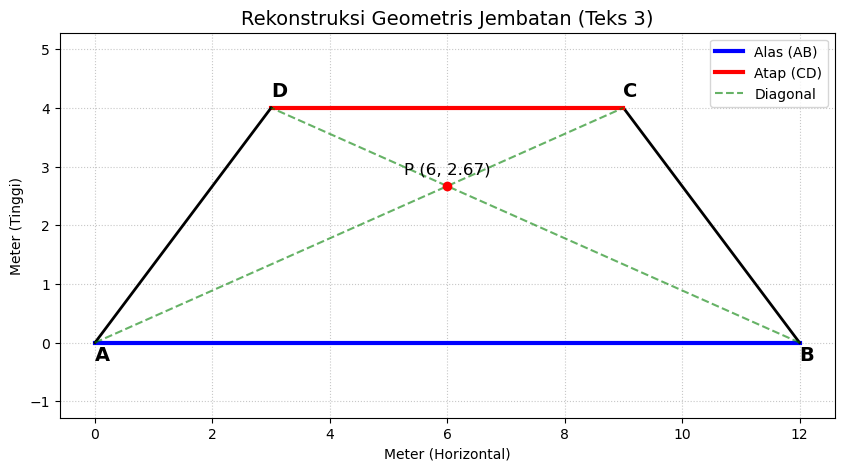

In [33]:
import matplotlib.pyplot as plt

# 1. Definisi Koordinat (Berdasarkan Data Teks 3)
# AB = 12m, CD = 6m, Tinggi = 4m
# Kita letakkan A di (0,0)
A = [0, 0]
B = [12, 0]

# Karena simetris, posisi x untuk D dan C adalah (12-6)/2 = 3
D = [3, 4]
C = [9, 4]

# Menghitung Titik Potong Diagonal P secara Matematis:
# Persamaan garis AC: y = (4/9)x
# Persamaan garis BD: y = (-4/9)x + 48/9
# P berada di x=6 (tengah), y=8/3 (~2.67)
P = [6, 8/3]

# 2. Plotting
plt.figure(figsize=(10, 5))

# Plot Sisi Luar Trapesium
plt.plot([A[0], B[0]], [A[1], B[1]], 'b-', linewidth=3, label='Alas (AB)')
plt.plot([B[0], C[0]], [B[1], C[1]], 'k-', linewidth=2)
plt.plot([C[0], D[0]], [C[1], D[1]], 'r-', linewidth=3, label='Atap (CD)')
plt.plot([D[0], A[0]], [D[1], A[1]], 'k-', linewidth=2)

# Plot Diagonal
plt.plot([A[0], C[0]], [A[1], C[1]], 'g--', alpha=0.6)
plt.plot([B[0], D[0]], [B[1], D[1]], 'g--', alpha=0.6, label='Diagonal')

# Plot Titik P
plt.plot(P[0], P[1], 'ro')
plt.text(P[0], P[1]+0.2, f'P ({P[0]}, {P[1]:.2f})', fontsize=12, ha='center')

# Label Titik-titik
labels = {'A': A, 'B': B, 'C': C, 'D': D}
for label, coord in labels.items():
    plt.text(coord[0], coord[1]-0.3 if coord[1]==0 else coord[1]+0.2, 
             label, fontsize=14, fontweight='bold')

# Styling Plot
plt.title("Rekonstruksi Geometris Jembatan (Teks 3)", fontsize=14)
plt.xlabel("Meter (Horizontal)")
plt.ylabel("Meter (Tinggi)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.axis('equal')
plt.legend()
plt.show()

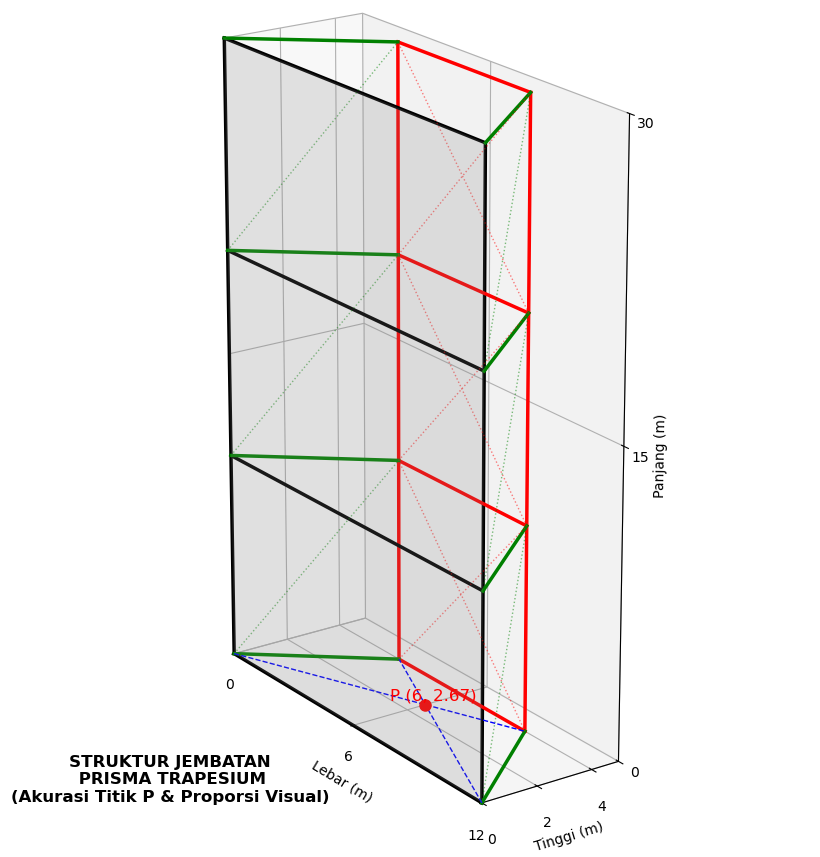

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. Parameter Dimensi (Teks 3)
W1 = 12   # Lebar Alas (AB)
W2 = 6    # Lebar Atap (CD)
H  = 4    # Tinggi
P1_len = 10 # Panjang per Panel
N_panels = 3 # Jumlah Panel
L_total = P1_len * N_panels # Total Panjang (Memanjang)

# Hitung koordinat P (X,Y) dari alas
# P berada di tengah (X=6)
# P_height = (H * W1) / (W1 + W2) = 2.67
Px, Py = 6, 8/3

# 2. Definisikan Titik-Titik Koordinat (X,Y,Z)
# Point lists for A, B, C, D along length
points_A, points_B, points_C, points_D, points_P = [], [], [], [], []

z_coords = np.linspace(0, L_total, N_panels + 1)
for z in z_coords:
    # A(0,0,z), B(12,0,z)
    # C(9,4,z), D(3,4,z) (Asumsi Simetris)
    points_A.append(np.array([0, 0, z]))
    points_B.append(np.array([12, 0, z]))
    points_C.append(np.array([9, 4, z]))
    points_D.append(np.array([3, 4, z]))
    points_P.append(np.array([Px, Py, z])) # Titik Pusat Diagonal

# 3. Plotting
fig = plt.figure(figsize=(12, 7))

# BUAT AXES DULU: Inisialisasi subplot 3D sebelum menambahkan elemen apa pun
ax = fig.add_subplot(111, projection='3d')

# BARU TAMBAHKAN KOLEKSI: Panggil add_collection3d melalui objek 'ax'
# (Baris ini opsional, hanya untuk inisialisasi surface kosong jika perlu)
# ax.add_collection3d(Poly3DCollection([], alpha=0.1)) 

# -- Lanjutkan ke Gambar Elemen Struktur --

# -- Gambar Elemen Struktur --
thickness_main = 2.5
thickness_bracing = 1.0

# 3.1 Main Longitudinal Chords (Balok Memanjang)
ax.plot([0, 0], [0, 0], [0, L_total], 'k-', lw=thickness_main) # A_chord
ax.plot([12, 12], [0, 0], [0, L_total], 'k-', lw=thickness_main) # B_chord
ax.plot([3, 3], [4, 4], [0, L_total], 'r-', lw=thickness_main) # D_chord
ax.plot([9, 9], [4, 4], [0, L_total], 'r-', lw=thickness_main) # C_chord

# 3.2 Transverse Frames (Bingkai Bent) & Vertical Posts
for i in range(N_panels + 1):
    A, B, C, D = points_A[i], points_B[i], points_C[i], points_D[i]
    
    # Floor Girder (AB) & Top Cross (DC)
    ax.plot([A[0], B[0]], [A[1], B[1]], [A[2], B[2]], 'k-', lw=thickness_main)
    ax.plot([C[0], D[0]], [C[1], D[1]], [C[2], D[2]], 'r-', lw=thickness_main)
    
    # Vertical Posts (AD & BC)
    ax.plot([A[0], D[0]], [A[1], D[1]], [A[2], D[2]], 'g-', lw=thickness_main)
    ax.plot([B[0], C[0]], [B[1], C[1]], [B[2], C[2]], 'g-', lw=thickness_main)

# 3.3 Diagonal Bracing (Penguat Silang)
for i in range(N_panels):
    A0, B0, C0, D0, P0 = points_A[i], points_B[i], points_C[i], points_D[i], points_P[i]
    A1, B1, C1, D1 = points_A[i+1], points_B[i+1], points_C[i+1], points_D[i+1]
    
    # Internal X-Bracing on Top Plane (DC -> CD')
    ax.plot([D0[0], C1[0]], [D0[1], C1[1]], [D0[2], C1[2]], 'r:', lw=thickness_bracing, alpha=0.5)
    ax.plot([C0[0], D1[0]], [C0[1], D1[1]], [C0[2], D1[2]], 'r:', lw=thickness_bracing, alpha=0.5)
    
    # Side Wall Bracing (AD -> DA') & (BC -> CB')
    ax.plot([A0[0], D1[0]], [A0[1], D1[1]], [A0[2], D1[2]], 'g:', lw=thickness_bracing, alpha=0.5)
    ax.plot([B0[0], C1[0]], [B0[1], C1[1]], [B0[2], C1[2]], 'g:', lw=thickness_bracing, alpha=0.5)

# 3.4 Front-Bent Diagonal (Structure 'P' as requested)
# Only draw the first bent diagonals to keep it clean and highlight 'P'
A_front, B_front, C_front, D_front = points_A[0], points_B[0], points_C[0], points_D[0]
ax.plot([A_front[0], C_front[0]], [A_front[1], C_front[1]], [A_front[2], C_front[2]], 'b--', lw=thickness_bracing)
ax.plot([B_front[0], D_front[0]], [B_front[1], D_front[1]], [B_front[2], D_front[2]], 'b--', lw=thickness_bracing)
ax.plot(Px, Py, 0, 'ro', markersize=8)
ax.text(Px, Py+0.3, 0.1, f"P ({Px}, {Py:.2f})", color='red', fontsize=12, ha='center')

# 3.5 Road Surface (Shading)
road_surface = [points_A[0], points_A[-1], points_B[-1], points_B[0]]
face = [tuple(p) for p in road_surface]
ax.add_collection3d(Poly3DCollection([face], facecolors='grey', alpha=0.2))

# -- Styling Plot (VERSI FIX FINAL: ANTI-KEPOTONG) --

# 1. Atur Ukuran Figure lebih lega (lebar x tinggi)
# figsize dibuat agak kotak supaya 3D punya ruang gerak
fig.set_size_inches(30, 10) 

# 2. BOX ASPECT: Kita atur ulang biar kelihatan mendatar (Jembatan)
# Rasio: Lebar(4), Tinggi(1.5), Panjang(6)
ax.set_box_aspect((4, 1.5, 6)) 

# 3. LABEL PAD: Kecilin dikit pad-nya biar nggak "lari" keluar frame
ax.set_xlabel('Lebar (m)', labelpad=5)
ax.set_ylabel('Tinggi (m)', labelpad=0)
ax.set_zlabel('Panjang (m)', labelpad=5)

# 4. LIMITS: Pas-in lagi biar nggak terlalu banyak ruang kosong (Zoom In)
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.set_zlim(0, 30)

# 5. TICKS: Bersihin biar nggak rame
ax.set_xticks([0, 6, 12])
ax.set_yticks([0, 2, 4])
ax.set_zticks([0, 15, 30])

# 6. VIEWPOINT: Sudut pandang jembatan yang lebih natural
ax.view_init(elev=20, azim=-35)

# 7. MARGIN FIX: Ini kunci biar label nggak kepotong
# Kita kasih ruang 15% di setiap sisi secara manual
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

# Judul diposisikan lebih ke bawah dikit biar nggak kepotong atasnya
plt.title("STRUKTUR JEMBATAN\n PRISMA TRAPESIUM\n(Akurasi Titik P & Proporsi Visual)", 
          fontsize=12, fontweight='bold', y=0.0, x=0.2)

plt.show()

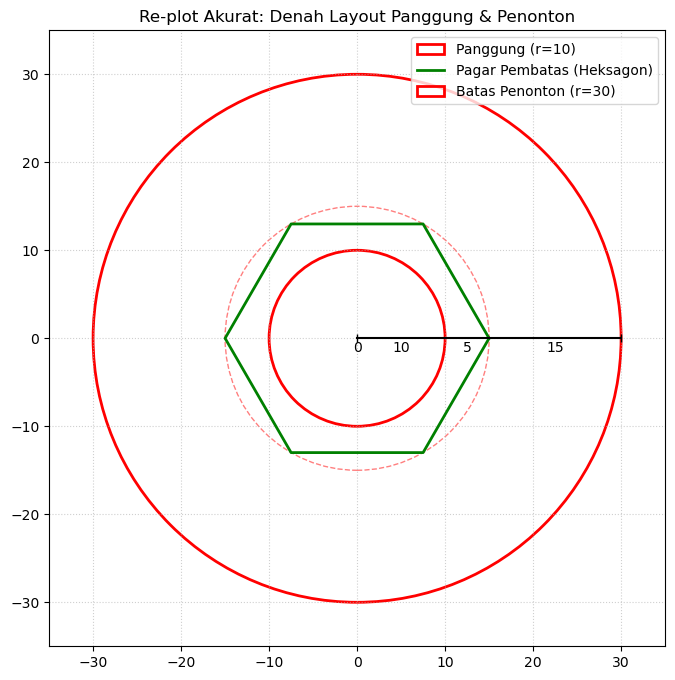

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def draw_concert_layout():
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Konfigurasi Jari-jari
    r_stage = 10
    r_fence = 15
    r_audience = 30
    
    # 1. Plot Lingkaran Panggung (Area 3)
    circle_stage = plt.Circle((0, 0), r_stage, color='red', fill=False, linewidth=2, label='Panggung (r=10)')
    ax.add_patch(circle_stage)
    
    # 2. Plot Lingkaran Pembatas (Tempat Heksagon berada)
    circle_mid = plt.Circle((0, 0), r_fence, color='red', fill=False, linestyle='--', alpha=0.5)
    ax.add_patch(circle_mid)
    
    # 3. Plot Pagar Pembatas (Heksagon Hijau)
    # Titik sudut heksagon: (r*cos(theta), r*sin(theta))
    angles = np.linspace(0, 2*np.pi, 7)
    hex_x = r_fence * np.cos(angles)
    hex_y = r_fence * np.sin(angles)
    ax.plot(hex_x, hex_y, color='green', linewidth=2, label='Pagar Pembatas (Heksagon)')
    
    # 4. Plot Lingkaran Penonton Terluar (Area 1)
    circle_outer = plt.Circle((0, 0), r_audience, color='red', fill=False, linewidth=2, label='Batas Penonton (r=30)')
    ax.add_patch(circle_outer)
    
    # Tambahkan garis skala (seperti di gambar)
    ax.plot([0, 30], [0, 0], color='black', marker='|')
    ax.text(5, -1.5, '10', ha='center')
    ax.text(12.5, -1.5, '5', ha='center')
    ax.text(22.5, -1.5, '15', ha='center')
    ax.text(0, -1.5, '0', ha='center')

    # Setting Tampilan
    ax.set_xlim(-35, 35)
    ax.set_ylim(-35, 35)
    ax.set_aspect('equal')
    plt.title("Re-plot Akurat: Denah Layout Panggung & Penonton")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()

draw_concert_layout()

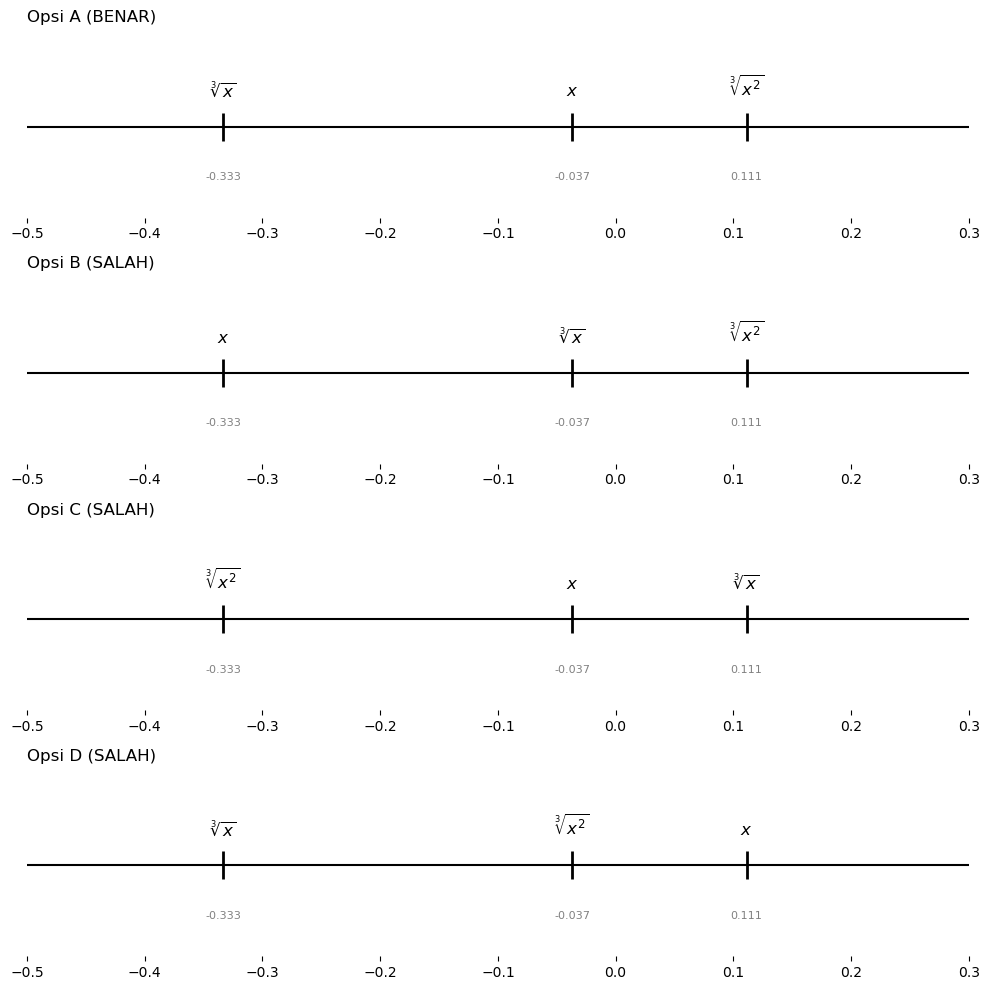

In [7]:
import matplotlib.pyplot as plt

def plot_opsi(labels_list, title, subplot_pos):
    # Koordinat asli berdasarkan x = -1/27
    val_x = -1/27          # ~ -0.037
    val_root3 = -1/3       # ~ -0.333
    val_root3sq = 1/9      # ~  0.111
    
    # Titik statis agar posisi centang (ticks) selalu sama di semua opsi
    posisi_ticks = sorted([val_x, val_root3, val_root3sq]) # [-0.33, -0.037, 0.11]
    
    plt.subplot(4, 1, subplot_pos)
    plt.axhline(0, color='black', linewidth=1.5)
    
    # Plot label sesuai urutan yang diberikan di list (ini yang bikin beda)
    for pos, teks in zip(posisi_ticks, labels_list):
        plt.plot(pos, 0, 'k|', markersize=20, markeredgewidth=2)
        plt.text(pos, 0.15, teks, ha='center', va='bottom', fontsize=12, fontweight='bold')
        # Menampilkan angka di bawah garis untuk bantu kamu ngecek skalanya
        plt.text(pos, -0.25, f'{pos:.3f}', ha='center', va='top', fontsize=8, color='gray')

    plt.title(title, loc='left', pad=10)
    plt.xlim(-0.5, 0.3)
    plt.ylim(-0.5, 0.5)
    plt.gca().get_yaxis().set_visible(False)
    for side in ['top', 'right', 'left', 'bottom']:
        plt.gca().spines[side].set_visible(False)

# Data Label
label_x = r'$x$'
label_r3 = r'$\sqrt[3]{x}$'
label_r3sq = r'$\sqrt[3]{x^2}$'

plt.figure(figsize=(10, 10))

# 1. Opsi A (BENAR): Urutan nilai terkecil ke terbesar adalah root3, x, lalu root3sq
plot_opsi([label_r3, label_x, label_r3sq], "Opsi A (BENAR)", 1)

# 2. Opsi B (SALAH): x ditaruh di paling kiri
plot_opsi([label_x, label_r3, label_r3sq], "Opsi B (SALAH)", 2)

# 3. Opsi C (SALAH): Urutan dibalik
plot_opsi([label_r3sq, label_x, label_r3], "Opsi C (SALAH)", 3)

# 4. Opsi D (SALAH): Akar pangkat 3 dari x^2 ditaruh di tengah
plot_opsi([label_r3, label_r3sq, label_x], "Opsi D (SALAH)", 4)

plt.tight_layout()
plt.show()